Section A: Constructing the Equal-Weighted Portfolio


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

DOWNLOADS_DIR = Path.home() / "Downloads"
prices = pd.read_csv(
     DOWNLOADS_DIR / "stock_prices.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

daily_returns = pd.read_csv(
    DOWNLOADS_DIR/"daily_returns.csv",
    index_col=0,
    parse_dates=[0]
).sort_index()

In [2]:
#annual returns and covariance matrix
annual_returns = ((1 + daily_returns).prod() ** (252 / len(daily_returns))) - 1

cov_matrix = daily_returns.cov() * 252

In [3]:
cov_matrix

,HDFC Bank,Infosys,Reliance,HUL
HDFC Bank,0.062079,0.020644,0.029194,0.014216
Infosys,0.020644,0.075423,0.023455,0.016775
Reliance,0.029194,0.023455,0.078942,0.018667
HUL,0.014216,0.016775,0.018667,0.050907


EQUALLY WEIGHTED PORTFOLIO

In [4]:
weights = np.array([0.25, 0.25, 0.25, 0.25])

In [5]:
portfolio_return = np.dot(weights, annual_returns)

In [6]:
portfolio_volatility = np.sqrt(
    np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )
)

In [7]:
risk_free_rate = 0.06

portfolio_sharpe = (
    portfolio_return - risk_free_rate
) / portfolio_volatility

In [8]:
#portfolio summary
equal_weighted = pd.DataFrame({

    "Annual Return":[portfolio_return],

    "Annual Volatility":[portfolio_volatility],

    "Sharpe Ratio":[portfolio_sharpe]

})

equal_weighted.round(3)


,Annual Return,Annual Volatility,Sharpe Ratio
0,0.127,0.179,0.376


PORTFOLIO GROWTH

In [9]:
portfolio_daily_returns = daily_returns.dot(weights)

portfolio_growth = (
    1 + portfolio_daily_returns
    
).cumprod()

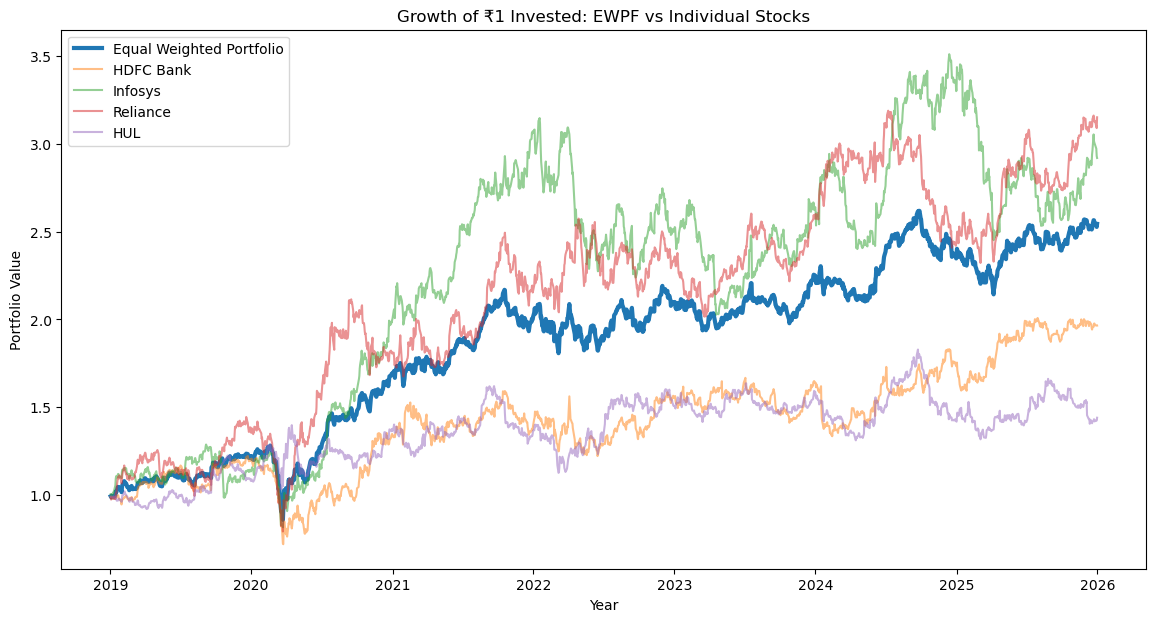

In [10]:
plt.figure(figsize=(14,7))

plt.plot(
    portfolio_growth,
    linewidth=3,
    label="Equal Weighted Portfolio"
)

for stock in prices.columns:

    plt.plot(
        (1 + daily_returns[stock]).cumprod(),
        alpha=0.5,
        label=stock
    )

plt.legend()

plt.title("Growth of ₹1 Invested: EWPF vs Individual Stocks")

plt.ylabel("Portfolio Value")

plt.xlabel("Year")

plt.show()

RANDOM PORTFOLIO SIMULATION

In [11]:
#10,000 random portfolios with random weight assignments
num_portfolios = 10000

results = np.zeros((3, num_portfolios))

weights_record = []

In [12]:
for i in range(num_portfolios):

    weights = np.random.random(4)

    weights /= np.sum(weights)

    weights_record.append(weights)

    portfolio_return = np.dot(weights, annual_returns)

    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(cov_matrix, weights)
        )
    )

    sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    results[0, i] = portfolio_return

    results[1, i] = portfolio_volatility

    results[2, i] = sharpe #Sharpe Ratio. For every simulated portfolio, the Sharpe Ratio is calculated to measure the excess return earned for each unit of portfolio risk.This enables portfolios to be compared not only according to their returns but also according to the efficiency with which those returns are generated.

EFFICIENT FRONTIER

In [13]:
portfolio_results = pd.DataFrame({

    "Return":results[0],

    "Volatility":results[1],

    "Sharpe":results[2]

})

In [14]:
portfolio_results.head()

,Return,Volatility,Sharpe
0,0.133625,0.183129,0.402040
1,0.162364,0.207522,0.493267
2,0.090410,0.179970,0.168975
3,0.127500,0.182903,0.369049
4,0.140575,0.193923,0.415501


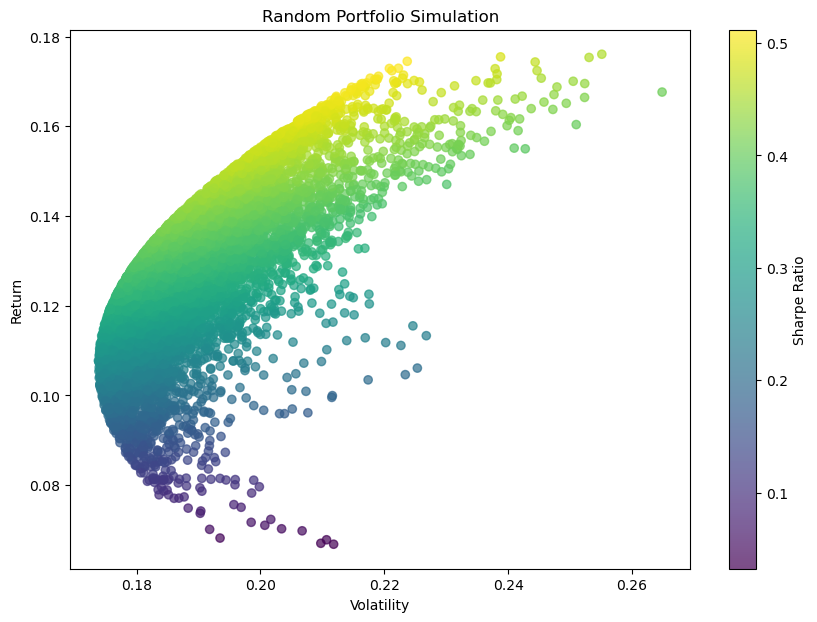

In [15]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(

    portfolio_results["Volatility"],

    portfolio_results["Return"],

    c=portfolio_results["Sharpe"],

    cmap="viridis",

    alpha=0.7

)

plt.colorbar(scatter,label="Sharpe Ratio")

plt.xlabel("Volatility")

plt.ylabel("Return")

plt.title("Random Portfolio Simulation")

plt.show()

IDENTIFY THE BEST PORTFOLIOS

In [16]:
#maximum sharpe
mc_max_sharpe = portfolio_results.iloc[
    portfolio_results["Sharpe"].idxmax()
]

mc_max_weights = weights_record[
    portfolio_results["Sharpe"].idxmax()
]

In [17]:
#minimum variance
mc_min_volatility = portfolio_results.iloc[
    portfolio_results["Volatility"].idxmin()
]

mc_min_weights = weights_record[
    portfolio_results["Volatility"].idxmin()
]

PORTFOLIO WEIGHTS

In [18]:
#max sharpe portfolio
max_weights_df = pd.DataFrame({

    "Weight":mc_max_weights

},

index=prices.columns)

max_weights_df

,Weight
HDFC Bank,0.004847
Infosys,0.419510
Reliance,0.562540
HUL,0.013103


In [19]:
#min variance portfolio
min_weights_df=pd.DataFrame({"Weight":mc_min_weights}, index=prices.columns)
min_weights_df

,Weight
HDFC Bank,0.267376
Infosys,0.195788
Reliance,0.138963
HUL,0.397874


HIGHLIGHT THE OPTIMAL PORTFOLIO

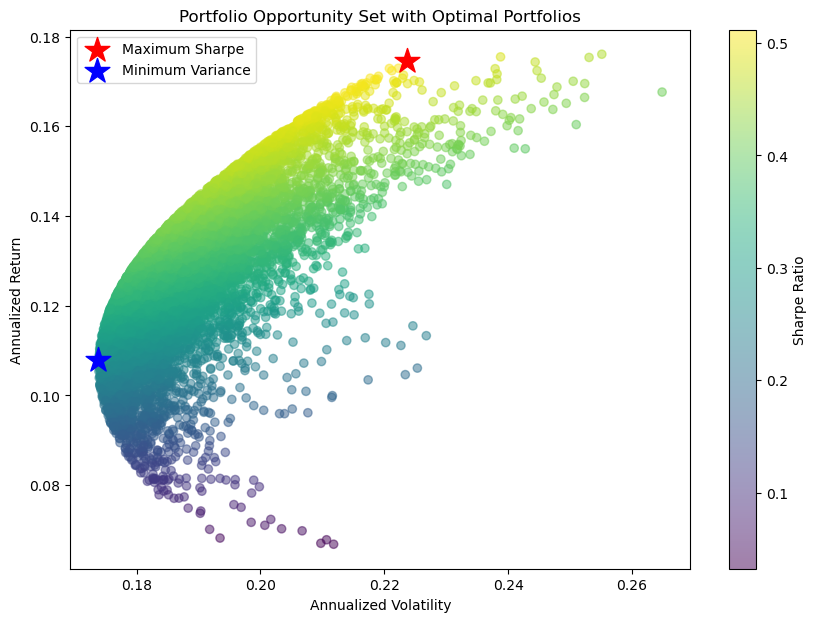

In [20]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(
    portfolio_results["Volatility"],
    portfolio_results["Return"],
    c=portfolio_results["Sharpe"],
    cmap="viridis",
    alpha=0.5
)

plt.scatter(
    mc_max_sharpe["Volatility"],
    mc_max_sharpe["Return"],
    color="red",
    marker="*",
    s=350,
    label="Maximum Sharpe"
)

plt.scatter(
    mc_min_volatility["Volatility"],
    mc_min_volatility["Return"],
    color="blue",
    marker="*",
    s=350,
    label="Minimum Variance"
)

plt.legend()
plt.colorbar(scatter, label="Sharpe Ratio")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.title("Portfolio Opportunity Set with Optimal Portfolios")

plt.show()

CONSTRAINED OPTIMISATION

In [21]:
from scipy.optimize import minimize

PORTFOLIO RETURN FUNCTION

In [22]:
def portfolio_return(weights):
    return np.dot(weights, annual_returns)

PORTFOLIO VOLATILITY FUNCTION

In [23]:
def portfolio_volatility(weights):

    return np.sqrt(

        np.dot(

            weights.T,

            np.dot(cov_matrix, weights)

        )

    )

SHARPE RATIO FUNCTION

In [24]:

risk_free_rate = 0.06

def negative_sharpe(weights):

    ret = portfolio_return(weights)

    vol = portfolio_volatility(weights)

    sharpe = (ret - risk_free_rate) / vol

    return -sharpe

Since the optimization routine minimizes objective functions by default, the negative Sharpe Ratio is returned. Minimizing the negative Sharpe Ratio is mathematically equivalent to maximizing the Sharpe Ratio itself.

CONSTRAINTS & BOUNDS

In [25]:
constraints = (

    {

        "type":"eq",

        "fun":lambda weights: np.sum(weights)-1

    },

)

In [26]:
bounds = (

    (0,1),

    (0,1),

    (0,1),

    (0,1)

)

INITIAL GUESS

In [27]:
#starting with ewpf
initial_weights = np.array(

    [0.25,0.25,0.25,0.25]

)

OPTIMISE MAXIMUM SHARPE

In [28]:
optimal = minimize(

    negative_sharpe,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)

In [29]:
optimal.success

True

EXTRACT THE OPTIMAL PORTFOLIO

In [30]:
optimal_weights = optimal.x

optimal_weights

array([0.        , 0.46330487, 0.53669513, 0.        ])

In [31]:
#converting to a table
optimal_weights_df = pd.DataFrame(
    {
        "Optimal Weight": optimal_weights
    },
    index=prices.columns
)

optimal_weights_df

,Optimal Weight
HDFC Bank,0.000000
Infosys,0.463305
Reliance,0.536695
HUL,0.000000


Calculate Portfolio Performance

In [32]:
optimal_return = portfolio_return(optimal_weights)

optimal_volatility = portfolio_volatility(optimal_weights)

optimal_sharpe = (
    optimal_return - risk_free_rate
) / optimal_volatility

MINIMUM VARIANCE PORTFOLIO

In [33]:
def portfolio_variance(weights):
    return portfolio_volatility(weights)

In [34]:
#optimise
minimum_variance = minimize(

    portfolio_variance,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)

In [35]:
#Extract weights
minimum_variance_weights = minimum_variance.x
minimum_variance_weights

array([0.26699556, 0.19692692, 0.12963017, 0.40644736])

In [36]:
#portfolio statistics
min_return = portfolio_return(minimum_variance_weights)

min_volatility = portfolio_volatility(minimum_variance_weights)

min_sharpe = (
    min_return - risk_free_rate
) / min_volatility

In [37]:
#compare ewpf, monte carlo simulation, and optimised weights
comparison = pd.DataFrame(
    {
        "Annual Return": [
            portfolio_return(np.array([0.25, 0.25, 0.25, 0.25])),
            mc_max_sharpe["Return"],
            optimal_return,
            mc_min_volatility["Return"],
            min_return
        ],

        "Annual Volatility": [
            portfolio_volatility(np.array([0.25, 0.25, 0.25, 0.25])),
            mc_max_sharpe["Volatility"],
            optimal_volatility,
            mc_min_volatility["Volatility"],
            min_volatility
        ],

        "Sharpe Ratio": [
            portfolio_sharpe,
            mc_max_sharpe["Sharpe"],
            optimal_sharpe,
            mc_min_volatility["Sharpe"],
            min_sharpe
        ],

        "Portfolio Weights": [
            initial_weights,
            np.round(mc_max_weights, 3),
            np.round(optimal_weights, 3),
            np.round(mc_min_weights,3),
            np.round(minimum_variance_weights,3)
        ]
    },

    index=[
        "Equal Weighted Portfolio",
        "Best Random Portfolio(Sharpe)",
        "Optimized Portfolio(Sharpe)",
        "Best Random Portfolio(Min Var)",
        "Optimised Minimum Variance Portfolio"
    ]
)
comparison

,Annual Return,Annual Volatility,Sharpe Ratio,Portfolio Weights
Equal Weighted Portfolio,0.127286,0.179105,0.375681,"[0.25, 0.25, 0.25, 0.25]"
Best Random Portfolio(Sharpe),0.174510,0.223696,0.511900,"[0.005, 0.42, 0.563, 0.013]"
Optimized Portfolio(Sharpe),0.175987,0.224928,0.515665,"[0.0, 0.463, 0.537, 0.0]"
Best Random Portfolio(Min Var),0.107792,0.173845,0.274914,"[0.267, 0.196, 0.139, 0.398]"
Optimised Minimum Variance Portfolio,0.106715,0.173822,0.268754,"[0.267, 0.197, 0.13, 0.406]"


ROBUSTNESS OF PORTFOLIO

In [38]:
#portfolio daily returns
equal_returns = daily_returns.dot(
    np.array([0.25, 0.25, 0.25, 0.25])
)

max_sharpe_returns = daily_returns.dot(
    optimal_weights
)

min_variance_returns = daily_returns.dot(
    minimum_variance_weights
)

In [39]:
#growth of ₹1
equal_growth = (1 + equal_returns).cumprod()

max_growth = (1 + max_sharpe_returns).cumprod()

min_growth = (1 + min_variance_returns).cumprod()

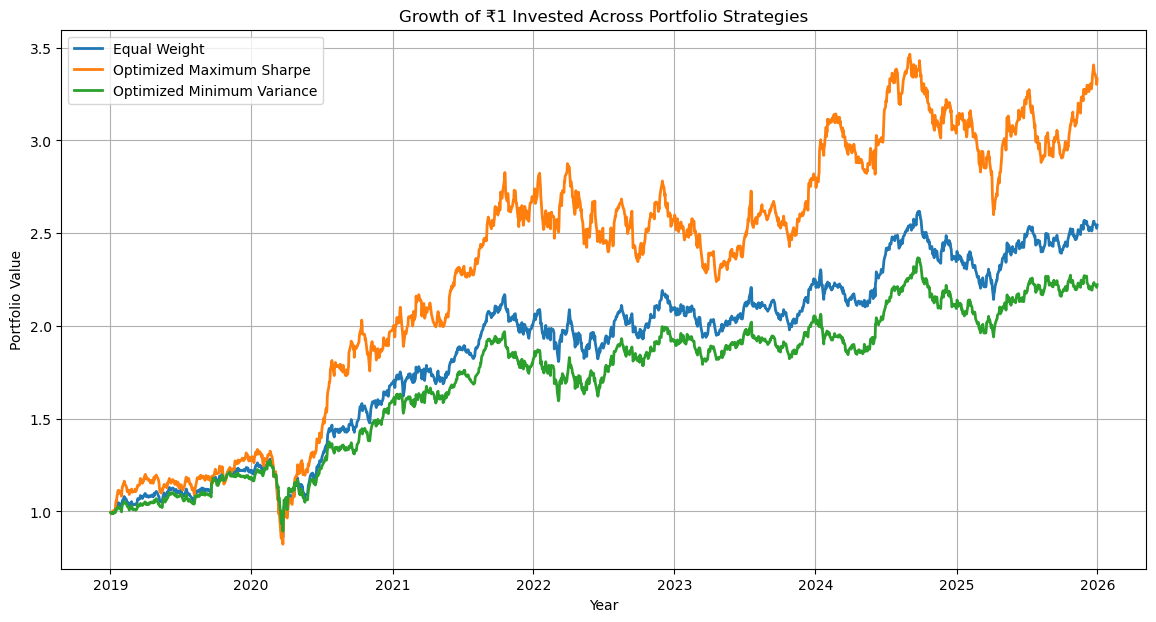

In [40]:
#plot of portfolio growth
plt.figure(figsize=(14,7))

plt.plot(equal_growth,
         label="Equal Weight",
         linewidth=2)

plt.plot(max_growth,
         label="Optimized Maximum Sharpe",
         linewidth=2)

plt.plot(min_growth,
         label="Optimized Minimum Variance",
         linewidth=2)

plt.title("Growth of ₹1 Invested Across Portfolio Strategies")

plt.xlabel("Year")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.legend()

plt.show()

In [41]:
#maximum drawdown function
def maximum_drawdown(cumulative_returns):

    running_max = cumulative_returns.cummax()

    drawdown = (
        cumulative_returns - running_max
    ) / running_max

    return drawdown.min()

In [42]:
#calculating max drawdown
equal_mdd = maximum_drawdown(equal_growth)

max_sharpe_mdd = maximum_drawdown(max_growth)

min_variance_mdd = maximum_drawdown(min_growth)

In [43]:
#daily returns for mc simulation
mc_max_returns = daily_returns.dot(mc_max_weights)

mc_min_returns = daily_returns.dot(mc_min_weights)

In [44]:
#cumulative growth
mc_max_growth = (1 + mc_max_returns).cumprod()

mc_min_growth = (1 + mc_min_returns).cumprod()

In [45]:
#max dd for mc simulation
mc_max_mdd = maximum_drawdown(mc_max_growth)

mc_min_mdd = maximum_drawdown(mc_min_growth)

In [46]:
benchmark_prices=pd.read_csv(DOWNLOADS_DIR/'nifty50.csv',
                             index_col=0,
                             parse_dates=[0]).sort_index()

COMPARISON WITH NIFTY

In [47]:
benchmark_prices.head()

,^NSEI
Date,
2019-01-02,10792.500000
2019-01-03,10672.250000
2019-01-04,10727.349609
2019-01-07,10771.799805
2019-01-08,10802.150391


In [48]:
#benchmark daily returns
benchmark_returns = benchmark_prices.pct_change().dropna()

In [49]:
#cumulative growth
benchmark_growth = (1 + benchmark_returns).cumprod()

In [50]:
#benchmark mdd
benchmark_mdd = maximum_drawdown(benchmark_growth)

Portfolio Maximum Drawdown

The Maximum Drawdown is calculated separately for each portfolio.

Lower absolute drawdowns indicate that a portfolio experienced smaller peak-to-trough losses and therefore demonstrated greater resilience during adverse market conditions.

In [51]:
#benchmark performance
benchmark_return = (
    (1 + benchmark_returns).prod() **
    (252 / len(benchmark_returns))
) - 1

benchmark_volatility = (
    benchmark_returns.std() *
    np.sqrt(252)
)

benchmark_sharpe = (
    benchmark_return - risk_free_rate
) / benchmark_volatility

benchmark_calmar = (
    benchmark_return /
    abs(benchmark_mdd)
)

In [52]:
#combined summary table
portfolio_summary = pd.DataFrame({

    "Annual Return": [

        portfolio_return(initial_weights)*100,
        mc_max_sharpe['Return']*100,
        optimal_return*100,
        mc_min_volatility['Return']*100,
        min_return*100,
        benchmark_return.iloc[0]*100

    ],

    "Annual Volatility": [

        portfolio_volatility(initial_weights)*100,
        mc_max_sharpe['Volatility']*100,

        optimal_volatility*100,
        mc_min_volatility['Volatility']*100,

        min_volatility*100,
        benchmark_volatility.iloc[0]*100

    ],

    "Sharpe Ratio": [

        portfolio_sharpe,
        mc_max_sharpe["Sharpe"],

        optimal_sharpe,
        mc_min_volatility["Sharpe"],

        min_sharpe,
        benchmark_sharpe.iloc[0]

    ]
},

index=[

    "Equal Weighted Portfolio",
    "MC Maximum Sharpe",

    "Optimized Maximum Sharpe",
    "MC Minimun Variance",

    "Optimized Minimum Variance",
    "NIFTY 50 Benchmark"

])

portfolio_summary.round(3)

,Annual Return,Annual Volatility,Sharpe Ratio
Equal Weighted Portfolio,12.729,17.910,0.376
MC Maximum Sharpe,17.451,22.370,0.512
Optimized Maximum Sharpe,17.599,22.493,0.516
MC Minimun Variance,10.779,17.384,0.275
Optimized Minimum Variance,10.672,17.382,0.269
NIFTY 50 Benchmark,13.780,17.568,0.443


In [53]:
#including max drawdown and calmar
portfolio_summary["Maximum Drawdown"] = [

    equal_mdd*100,
    mc_max_mdd*100,
    max_sharpe_mdd*100,
    mc_min_mdd*100,
    min_variance_mdd*100,
    benchmark_mdd.iloc[0]*100


]

portfolio_summary["Calmar Ratio"] = (

    portfolio_summary["Annual Return"] /

    portfolio_summary["Maximum Drawdown"].abs()

)

portfolio_summary.round(3)

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio
Equal Weighted Portfolio,12.729,17.910,0.376,-32.921,0.387
MC Maximum Sharpe,17.451,22.370,0.512,-38.443,0.454
Optimized Maximum Sharpe,17.599,22.493,0.516,-38.315,0.459
MC Minimun Variance,10.779,17.384,0.275,-29.948,0.360
Optimized Minimum Variance,10.672,17.382,0.269,-29.746,0.359
NIFTY 50 Benchmark,13.780,17.568,0.443,-38.440,0.358


Calmar Ratio

Higher Calmar Ratios indicate that a portfolio generated stronger returns relative to the largest historical loss experienced by investors.

In [54]:
# ============================================================
# Portfolio Daily Returns
# ============================================================

mc_max_sharpe_returns = daily_returns.dot(mc_max_weights)

mc_min_var_returns = daily_returns.dot(mc_min_weights)



In [55]:
portfolio_returns_df = pd.concat(
    [
        equal_returns,
        mc_max_returns,
        max_sharpe_returns,
        mc_min_returns,
        min_variance_returns,
        benchmark_returns
    ],
    axis=1
).dropna()

In [56]:
portfolio_returns_df.shape

(1726, 6)

In [57]:
portfolio_returns_df.columns=['Equal Weighted Portfolio', 'MC Maximum Sharpe',
       'Optimized Maximum Sharpe', 'MC Minimun Variance',
       'Optimized Minimum Variance', 'NIFTY 50 Benchmark']

In [58]:
portfolio_returns_df

,Equal Weighted Portfolio,MC Maximum Sharpe,Optimized Maximum Sharpe,MC Minimun Variance,Optimized Minimum Variance,NIFTY 50 Benchmark
Date,,,,,,
2019-01-03,-0.004476,-0.006888,-0.006552,-0.002936,-0.002799,-0.011142
2019-01-04,-0.001944,-0.002077,-0.002711,-0.002395,-0.002492,0.005163
2019-01-07,0.006250,0.009913,0.010444,0.005056,0.005037,0.004144
2019-01-08,-0.004692,-0.001225,-0.001187,-0.005862,-0.005928,0.002818
2019-01-09,0.007276,0.007031,0.007147,0.007469,0.007494,0.004906
...,...,...,...,...,...,...
2025-12-24,-0.004788,-0.005822,-0.005632,-0.005045,-0.005050,-0.001339
2025-12-26,-0.001865,-0.001486,-0.001689,-0.001580,-0.001577,-0.003818
2025-12-29,-0.003138,-0.007751,-0.007870,-0.001292,-0.001189,-0.003848


In [59]:
market_variance = portfolio_returns_df["NIFTY 50 Benchmark"].var()

beta_results = {}
portfolios = ['Equal Weighted Portfolio', 'MC Maximum Sharpe',
       'Optimized Maximum Sharpe', 'MC Minimun Variance',
       'Optimized Minimum Variance', 'NIFTY 50 Benchmark']

for portfolio in portfolios:
    
    covariance = portfolio_returns_df[portfolio].cov(
        portfolio_returns_df["NIFTY 50 Benchmark"]
    )
    
    beta_results[portfolio] = (covariance / market_variance)

beta_results = pd.Series(
    beta_results,
    name="CAPM Beta"
)

beta_results_df=pd.DataFrame(beta_results)

In [60]:
beta_results_df

,CAPM Beta
Equal Weighted Portfolio,0.899439
MC Maximum Sharpe,0.995300
Optimized Maximum Sharpe,0.992064
MC Minimun Variance,0.832013
Optimized Minimum Variance,0.827128
NIFTY 50 Benchmark,1.000000


In [61]:
portfolio_summary_final=pd.concat([portfolio_summary,beta_results_df],axis=1)

In [62]:
portfolio_summary=portfolio_summary_final.round(3)
portfolio_summary

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,Calmar Ratio,CAPM Beta
Equal Weighted Portfolio,12.729,17.910,0.376,-32.921,0.387,0.899
MC Maximum Sharpe,17.451,22.370,0.512,-38.443,0.454,0.995
Optimized Maximum Sharpe,17.599,22.493,0.516,-38.315,0.459,0.992
MC Minimun Variance,10.779,17.384,0.275,-29.948,0.360,0.832
Optimized Minimum Variance,10.672,17.382,0.269,-29.746,0.359,0.827
NIFTY 50 Benchmark,13.780,17.568,0.443,-38.440,0.358,1.000


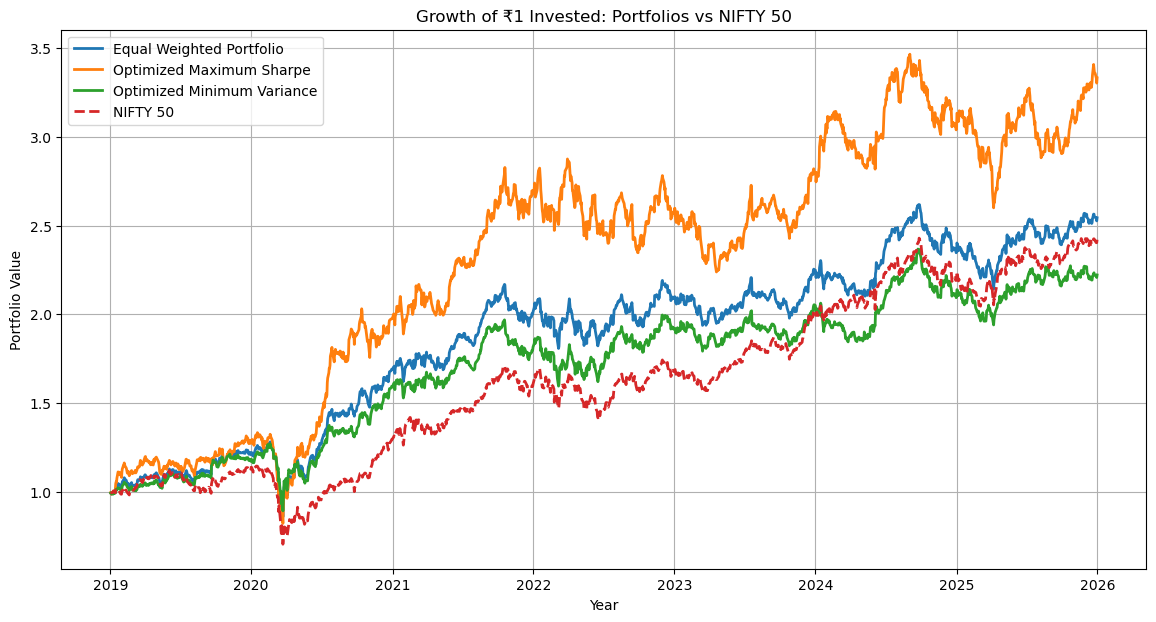

In [63]:
plt.figure(figsize=(14,7))

plt.plot(equal_growth,
         linewidth=2,
         label="Equal Weighted Portfolio")

plt.plot(max_growth,
         linewidth=2,
         label="Optimized Maximum Sharpe")

plt.plot(min_growth,
         linewidth=2,
         label="Optimized Minimum Variance")

plt.plot(benchmark_growth,
         linewidth=2,
         linestyle="--",
         label="NIFTY 50")

plt.title("Growth of ₹1 Invested: Portfolios vs NIFTY 50")

plt.xlabel("Year")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.legend()

plt.show()

In [64]:
portfolios = {
  "Equal returns": equal_returns.squeeze(),
"Max-Sharpe":max_sharpe_returns.squeeze(),
"Min-Variance":min_variance_returns.squeeze(),
"Benchmark Returns":benchmark_returns.squeeze()
}

for name, returns in portfolios.items():
    losses = -returns

    var = np.percentile(losses, 95)
    cvar = losses[losses >= var].mean()

    print(f"{name}")
    print(f"VaR (95%):  {var:.2%}")
    print(f"CVaR (95%): {cvar:.2%}")
    print()

Equal returns
VaR (95%):  1.45%
CVaR (95%): 2.41%

Max-Sharpe
VaR (95%):  1.86%
CVaR (95%): 3.04%

Min-Variance
VaR (95%):  1.45%
CVaR (95%): 2.30%

Benchmark Returns
VaR (95%):  1.50%
CVaR (95%): 2.58%

